In [1]:
# Social Network Ads Purchase Prediction using Decision Tree
# Author: Manikandaprabhu.S
# Objective: Predict whether a user will purchase a product based on Age, Estimated Salary, and Gender.

In [2]:
## 1. Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
## 3. Exploring the Dataset
data = pd.get_dummies(dataset,"Gender",dtype = int)
## 4. Handling Categorical Variables (Gender Encoding)
d = data.drop(["User ID","Gender_Female"], axis=1)
d

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1
...,...,...,...,...
395,46,41000,1,0
396,51,23000,1,1
397,50,20000,1,0
398,36,33000,0,1


In [5]:
## 5. Checking Dataset Information
d["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [6]:
d.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [7]:
## 6. Preparing Features and Target Variable
Features = d[['Age', 'EstimatedSalary', 'Gender_Male']]
Target = d["Purchased"]

In [8]:
## 7. Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(Features,Target,test_size=1/3,random_state=0)

In [9]:
## 8. Training Decision Tree Model with Hyperparameter Tuning (GridSearchCV)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'criterion':['gini','entropy'],
              'max_features': ['auto','sqrt','log2'],
              'splitter':['best','random']} 



grid_model = GridSearchCV(DecisionTreeClassifier(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted')  
   
## 9. fitting the model for grid search 
grid_model.fit(X_train, Y_train) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\ace

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [10]:
## 10. print best parameter after tuning 
print("The R_score value for best parameter {}:".format(grid_model.best_params_))

The R_score value for best parameter {'criterion': 'gini', 'max_features': 'sqrt', 'splitter': 'random'}:


In [11]:

re=grid_model.cv_results_
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002583,0.000812,0.000000,0.000000,gini,auto,best,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
1,0.002574,0.000938,0.000000,0.000000,gini,auto,random,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
2,0.012695,0.007126,0.015020,0.004168,gini,sqrt,best,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.829615,0.793754,0.832483,0.813179,0.885265,0.830859,0.030508,5
3,0.007731,0.002658,0.008899,0.002293,gini,sqrt,random,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.864871,0.886792,0.759244,0.865054,0.906166,0.856426,0.050963,1
4,0.005423,0.001028,0.008893,0.001645,gini,log2,best,"{'criterion': 'gini', 'max_features': 'log2', ...",0.776290,0.849057,0.796284,0.870362,0.847020,0.827803,0.035438,6
5,0.004724,0.000842,0.007110,0.001072,gini,log2,random,"{'criterion': 'gini', 'max_features': 'log2', ...",0.864871,0.790949,0.795256,0.868632,0.796094,0.823161,0.035654,8
6,0.001392,0.000820,0.000000,0.000000,entropy,auto,best,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
7,0.001098,0.002195,0.000000,0.000000,entropy,auto,random,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
8,0.006499,0.004479,0.010585,0.003000,entropy,sqrt,best,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.759544,0.832918,0.773585,0.906166,0.905069,0.835456,0.062359,4
9,0.004769,0.000370,0.006505,0.001238,entropy,sqrt,random,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.832255,0.831253,0.704089,0.886792,0.867097,0.824297,0.063717,7


In [12]:

y_pred = grid_model.predict(X_test) 

In [13]:
## 11. Evaluating the Model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
cm

array([[76,  9],
       [ 5, 44]])

In [14]:
## 12. Confusion Matrix
from sklearn.metrics import classification_report
clf_report = classification_report(Y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.94      0.89      0.92        85
           1       0.83      0.90      0.86        49

    accuracy                           0.90       134
   macro avg       0.88      0.90      0.89       134
weighted avg       0.90      0.90      0.90       134



In [15]:
grid_model.predict([[46,41000,0]])

C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

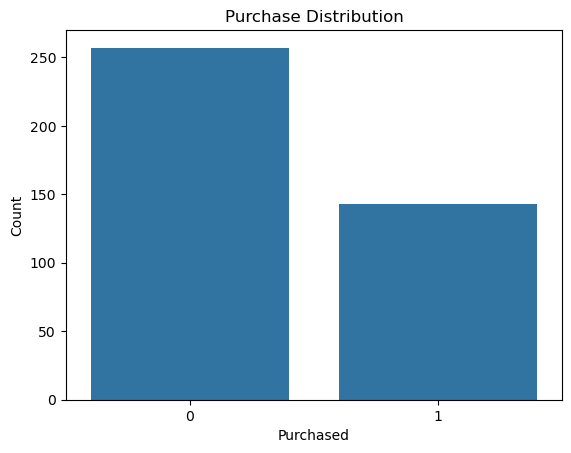

In [16]:
## 13. Visualizing Model Performance
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Purchased', data=d)

plt.title('Purchase Distribution')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()

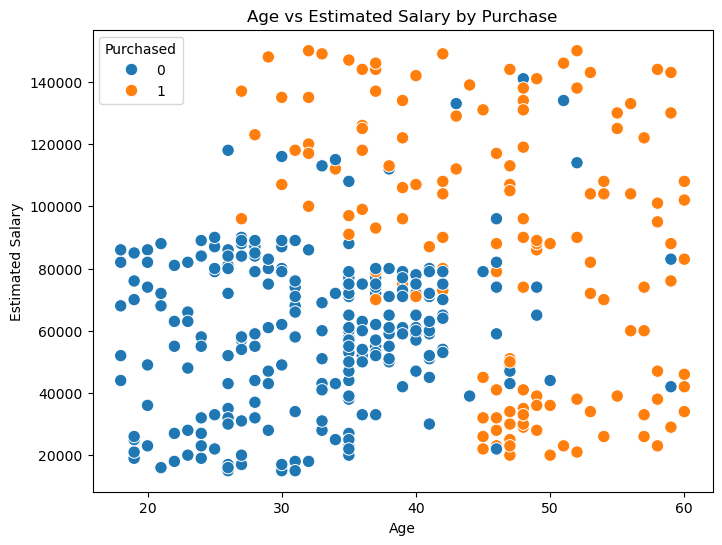

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=d,
    s=80
)

plt.title('Age vs Estimated Salary by Purchase')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

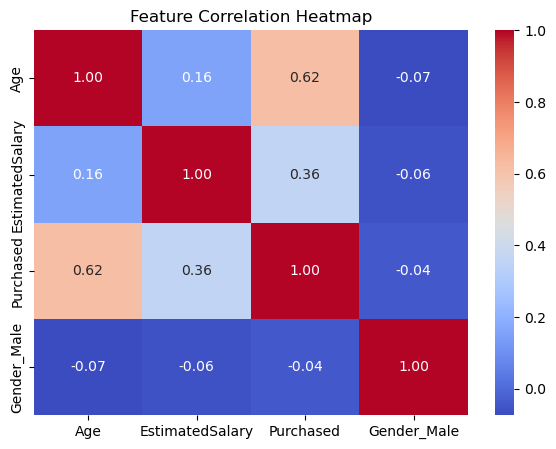

In [18]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    d.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

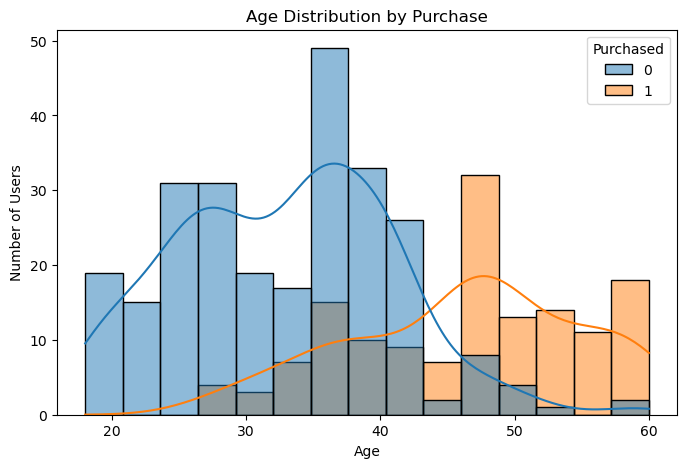

In [22]:
## 13.1 Age Distribution by Purchase

plt.figure(figsize=(8, 5))

sns.histplot(
    data=d,
    x='Age',
    hue='Purchased',
    kde=True,
    bins=15
)

plt.title('Age Distribution by Purchase')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

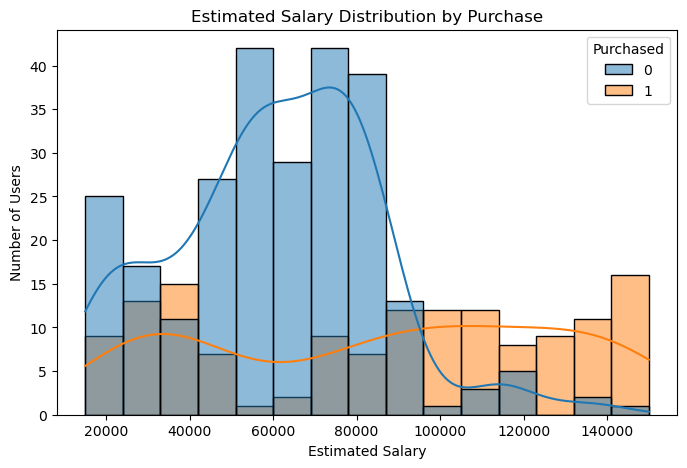

In [21]:
## 13.2 Estimated Salary Distribution by Purchase

plt.figure(figsize=(8, 5))

sns.histplot(
    data=d,
    x='EstimatedSalary',
    hue='Purchased',
    kde=True,
    bins=15
)

plt.title('Estimated Salary Distribution by Purchase')
plt.xlabel('Estimated Salary')
plt.ylabel('Number of Users')
plt.show()

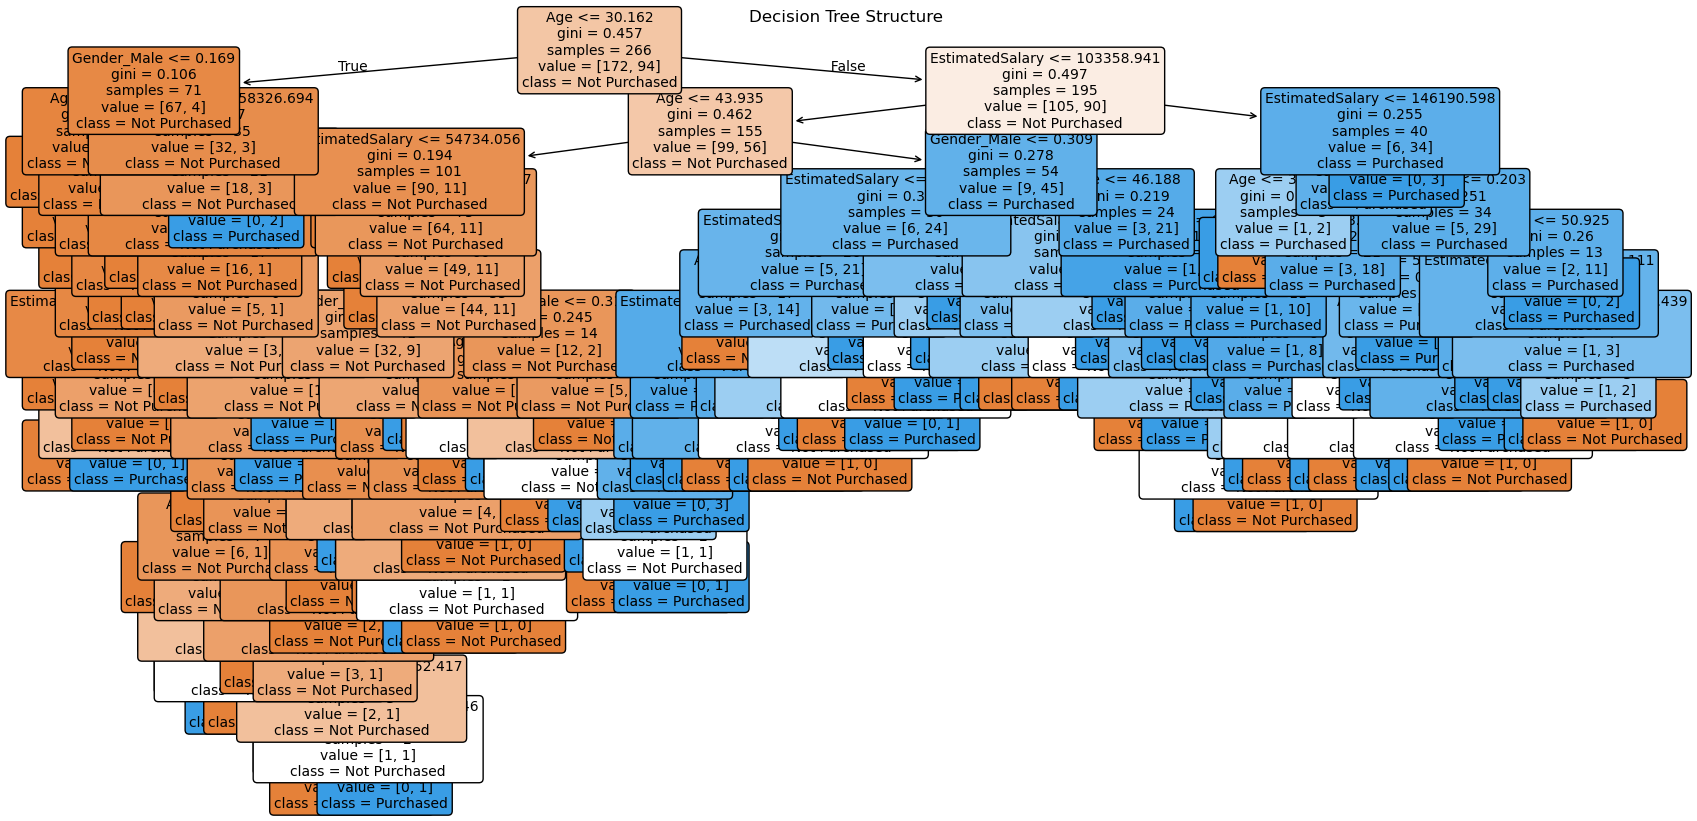

In [20]:
## 13.3 Decision Tree Visualization

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    grid_model.best_estimator_,
    feature_names=Features.columns,
    class_names=['Not Purchased', 'Purchased'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Decision Tree Structure')
plt.show()

In [19]:
## 14. Saving the Trained Model
import pickle
filename = "Finalized_model.sav"
save_model = pickle.dump(grid_model, open(filename, 'wb'))